In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from segment_anything import sam_model_registry, SamPredictor
import supervision as sv

# Check if CUDA is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

/home/ubuntu/additional_drive/yolo_exp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# Download SAM model checkpoint (only needed once)
import urllib.request
import os

# Create checkpoints directory
os.makedirs("checkpoints", exist_ok=True)

# Download SAM model if not exists
sam_checkpoint = "checkpoints/sam_vit_h_4b8939.pth"
if not os.path.exists(sam_checkpoint):
    print("Downloading SAM model (this may take a few minutes)...")
    url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
    urllib.request.urlretrieve(url, sam_checkpoint)
    print("Download complete!")

# Load Grounding DINO model
print("Loading Grounding DINO model...")
model_id = "IDEA-Research/grounding-dino-tiny"
processor = AutoProcessor.from_pretrained(model_id)
grounding_model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)

# Load SAM model
print("Loading SAM model...")
sam = sam_model_registry["vit_h"](checkpoint=sam_checkpoint)
sam.to(device=device)
sam_predictor = SamPredictor(sam)

print("Models loaded successfully!")

Download complete!
Loading Grounding DINO model...
Loading SAM model...
Models loaded successfully!


In [5]:
def annotate_image(image_path, prompt, confidence_threshold=0.3):
    """
    Annotate objects in an image based on text prompt
    
    Args:
        image_path: Path to input image
        prompt: Text description of what to annotate (e.g., "chip packet")
        confidence_threshold: Minimum confidence score (0-1)
    
    Returns:
        annotated_image: Image with annotations
        masks: Binary masks for detected objects
        boxes: Bounding boxes for detected objects
    """
    
    # Load image
    image = Image.open(image_path)
    image_np = np.array(image)
    
    # Detect objects with Grounding DINO
    inputs = processor(images=image, text=prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = grounding_model(**inputs)
    
    # Post-process results - FIXED VERSION
    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=confidence_threshold,  # Single threshold parameter
        target_sizes=[image.size[::-1]]
    )
    
    # Extract boxes and labels
    boxes = results[0]["boxes"].cpu().numpy()
    labels = results[0]["labels"]
    scores = results[0]["scores"].cpu().numpy()
    
    if len(boxes) == 0:
        print(f"No '{prompt}' detected in the image!")
        return image_np, [], []
    
    print(f"Detected {len(boxes)} object(s): {labels}")
    print(f"Confidence scores: {scores}")
    
    # Generate masks using SAM
    sam_predictor.set_image(image_np)
    
    # Convert boxes to SAM format (xyxy)
    masks_list = []
    for box in boxes:
        box_xyxy = box  # Already in xyxy format
        masks, scores_sam, logits = sam_predictor.predict(
            box=box_xyxy,
            multimask_output=False
        )
        masks_list.append(masks[0])
    
    masks_array = np.array(masks_list)
    
    # Create annotated image
    annotated_image = image_np.copy()
    
    # Draw masks
    for i, mask in enumerate(masks_array):
        # Random color for each mask
        color = np.random.randint(0, 255, size=3)
        annotated_image[mask] = annotated_image[mask] * 0.5 + color * 0.5
    
    # Draw bounding boxes
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(annotated_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        # Add label
        label_text = f"{labels[i]}: {scores[i]:.2f}"
        cv2.putText(annotated_image, label_text, (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    
    return annotated_image, masks_array, boxes

Detected 2 object(s): ['##te', '##te']
Confidence scores: [0.34128046 0.26813284]


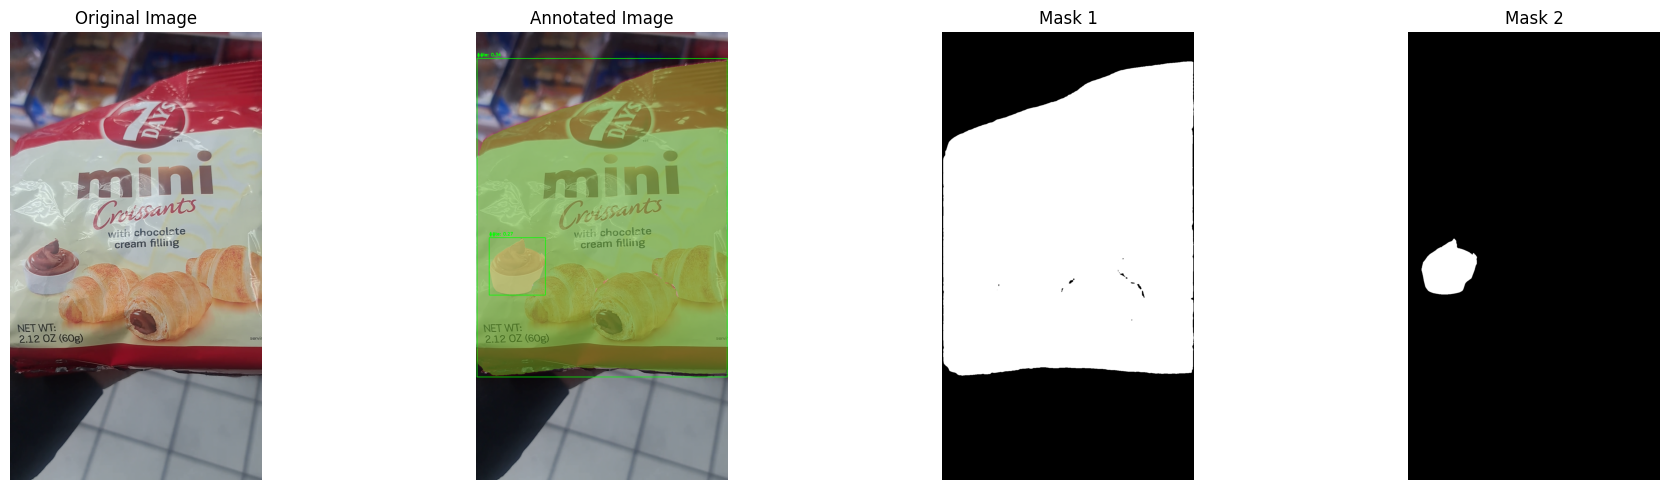


Annotated image saved as 'annotated_output.jpg'
Number of masks generated: 2
Mask 1 saved as 'mask_1.png'
Mask 2 saved as 'mask_2.png'


In [10]:
# Example usage
#  ["mini_croissant"]
image_path = "/home/ubuntu/additional_drive/shwan_data/scripts/all_frames/7_days_mini_croissants__816374020670__5/7_days_mini_croissants__816374020670__5_frame_001.png"  # Replace with your image path
prompt = "annotate chips packet only"  # What to annotate

# Run annotation
annotated_img, masks, boxes = annotate_image(image_path, prompt, confidence_threshold=0.25)

# Display results
display_results(image_path, annotated_img, masks)

# Save results
cv2.imwrite("annotated_output.jpg", cv2.cvtColor(annotated_img, cv2.COLOR_RGB2BGR))
print(f"\nAnnotated image saved as 'annotated_output.jpg'")
print(f"Number of masks generated: {len(masks)}")

# Save individual masks
for i, mask in enumerate(masks):
    mask_uint8 = (mask * 255).astype(np.uint8)
    cv2.imwrite(f"mask_{i+1}.png", mask_uint8)
    print(f"Mask {i+1} saved as 'mask_{i+1}.png'")